In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Guardame el df original
df_original = df.copy()

---
# 🔨 Procesamiento de Datos

In [3]:
# Transform categorical data into dummies
dummy_col = [column for column in df.drop('Attrition', axis=1).columns if df[column].nunique() < 20]
data = pd.get_dummies(df, columns=dummy_col, drop_first=True, dtype='uint8')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Columns: 137 entries, Age to YearsWithCurrManager_17
dtypes: int64(9), object(1), uint8(127)
memory usage: 297.3+ KB


In [4]:
print(data.shape)

# Remove duplicate Features
data = data.T.drop_duplicates()
data = data.T

# Remove Duplicate Rows
data.drop_duplicates(inplace=True)

print(data.shape)

(1470, 137)
(1470, 137)


In [5]:
data.shape

(1470, 137)

In [6]:
# data.drop('Attrition', axis=1).corrwith(data.Attrition).sort_values().plot(kind='barh', figsize=(10, 30))

In [7]:
# feature_correlation = data.drop('Attrition', axis=1).corrwith(data.Attrition).sort_values()
# model_col = feature_correlation[np.abs(feature_correlation) > 0.02].index
# len(model_col)

# 🤖 Experimentando con modelos de Machine Learning

In [8]:
X = data.drop('Attrition', axis=1)
y = data.Attrition

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,
                                                    stratify=y)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
X_std = scaler.transform(X)

In [9]:
X_train

,Age,DailyRate,DistanceFromHome,EmployeeNumber,HourlyRate,MonthlyIncome,MonthlyRate,TotalWorkingYears,YearsAtCompany,BusinessTravel_Travel_Frequently,...,YearsWithCurrManager_8,YearsWithCurrManager_9,YearsWithCurrManager_10,YearsWithCurrManager_11,YearsWithCurrManager_12,YearsWithCurrManager_13,YearsWithCurrManager_14,YearsWithCurrManager_15,YearsWithCurrManager_16,YearsWithCurrManager_17
853,19,645,9,1193,54,2552,7172,1,1,0,...,0,0,0,0,0,0,0,0,0,0
435,33,1277,15,582,56,13610,24619,15,7,0,...,0,0,0,0,0,0,0,0,0,0
587,52,1325,11,813,82,3149,21821,9,5,0,...,0,0,0,0,0,0,0,0,0,0
1170,27,591,2,1648,87,2580,6297,6,4,1,...,0,0,0,0,0,0,0,0,0,0
159,34,303,2,216,75,2231,11314,6,4,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,46,1144,7,487,30,5258,16044,7,1,0,...,0,0,0,0,0,0,0,0,0,0
963,38,1009,2,1355,31,6893,19461,11,7,0,...,0,0,0,0,0,0,0,0,0,0
734,22,217,8,1019,94,2451,6881,4,4,0,...,0,0,0,0,0,0,0,0,0,0
1315,36,430,2,1847,73,6962,19573,15,1,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
def feature_imp(df, model):
    fi = pd.DataFrame()
    fi["feature"] = df.columns
    fi["importance"] = model.feature_importances_
    return fi.sort_values(by="importance", ascending=False)

## 🎯 ¿Qué define el éxito?
> Tenemos un conjunto de datos desbalanceado, por lo que si predecimos que todos nuestros empleados permanecerán en la empresa obtendríamos una exactitud (**accuracy**) de `83.90%`.

In [11]:
y_test.value_counts()[0] / y_test.shape[0]

/var/folders/wx/t9s6p1v53nsd837jlvky50n80000gn/T/ipykernel_4474/1927410138.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_test.value_counts()[0] / y_test.shape[0]


np.float64(0.8390022675736961)

In [12]:
stay = (y_train.value_counts()[0] / y_train.shape)[0]
leave = (y_train.value_counts()[1] / y_train.shape)[0]

print("===============TRAIN=================")
print(f"Staying Rate: {stay * 100:.2f}%")
print(f"Leaving Rate: {leave * 100 :.2f}%")

stay = (y_test.value_counts()[0] / y_test.shape)[0]
leave = (y_test.value_counts()[1] / y_test.shape)[0]

print("===============TEST=================")
print(f"Staying Rate: {stay * 100:.2f}%")
print(f"Leaving Rate: {leave * 100 :.2f}%")

===============TRAIN=================
Staying Rate: 83.87%
Leaving Rate: 16.13%
===============TEST=================
Staying Rate: 83.90%
Leaving Rate: 16.10%


/var/folders/wx/t9s6p1v53nsd837jlvky50n80000gn/T/ipykernel_4474/329314148.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  stay = (y_train.value_counts()[0] / y_train.shape)[0]
/var/folders/wx/t9s6p1v53nsd837jlvky50n80000gn/T/ipykernel_4474/329314148.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  leave = (y_train.value_counts()[1] / y_train.shape)[0]
/var/folders/wx/t9s6p1v53nsd837jlvky50n80000gn/T/ipykernel_4474/329314148.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To

In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score

def evaluate(model, X_train, X_test, y_train, y_test):
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    print("TRAINIG RESULTS: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_train, y_train_pred, output_dict=True))
    print(f"CONFUSION MATRIX:\n{confusion_matrix(y_train, y_train_pred)}")
    print(f"ACCURACY SCORE:\n{accuracy_score(y_train, y_train_pred):.4f}")
    print(f"CLASSIFICATION REPORT:\n{clf_report}")

    print("TESTING RESULTS: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_test, y_test_pred, output_dict=True))
    print(f"CONFUSION MATRIX:\n{confusion_matrix(y_test, y_test_pred)}")
    print(f"ACCURACY SCORE:\n{accuracy_score(y_test, y_test_pred):.4f}")
    print(f"CLASSIFICATION REPORT:\n{clf_report}")

In [14]:
le = LabelEncoder()
y_train_numeric = le.fit_transform(y_train)
y_test_numeric = le.transform(y_test)

## ✔️ Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(solver='liblinear', penalty='l1')
lr_clf.fit(X_train_std, y_train)

evaluate(lr_clf, X_train_std, X_test_std, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[848  15]
 [ 59 107]]
ACCURACY SCORE:
0.9281
CLASSIFICATION REPORT:
                   No         Yes  accuracy    macro avg  weighted avg
precision    0.934950    0.877049  0.928086     0.906000      0.925610
recall       0.982619    0.644578  0.928086     0.813599      0.928086
f1-score     0.958192    0.743056  0.928086     0.850624      0.923486
support    863.000000  166.000000  0.928086  1029.000000   1029.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[351  19]
 [ 43  28]]
ACCURACY SCORE:
0.8594
CLASSIFICATION REPORT:
                   No        Yes  accuracy   macro avg  weighted avg
precision    0.890863   0.595745   0.85941    0.743304      0.843350
recall       0.948649   0.394366   0.85941    0.671507      0.859410
f1-score     0.918848   0.474576   0.85941    0.696712      0.847321
support    370.000000  71.000000   0.85941  441.000000    441.000000


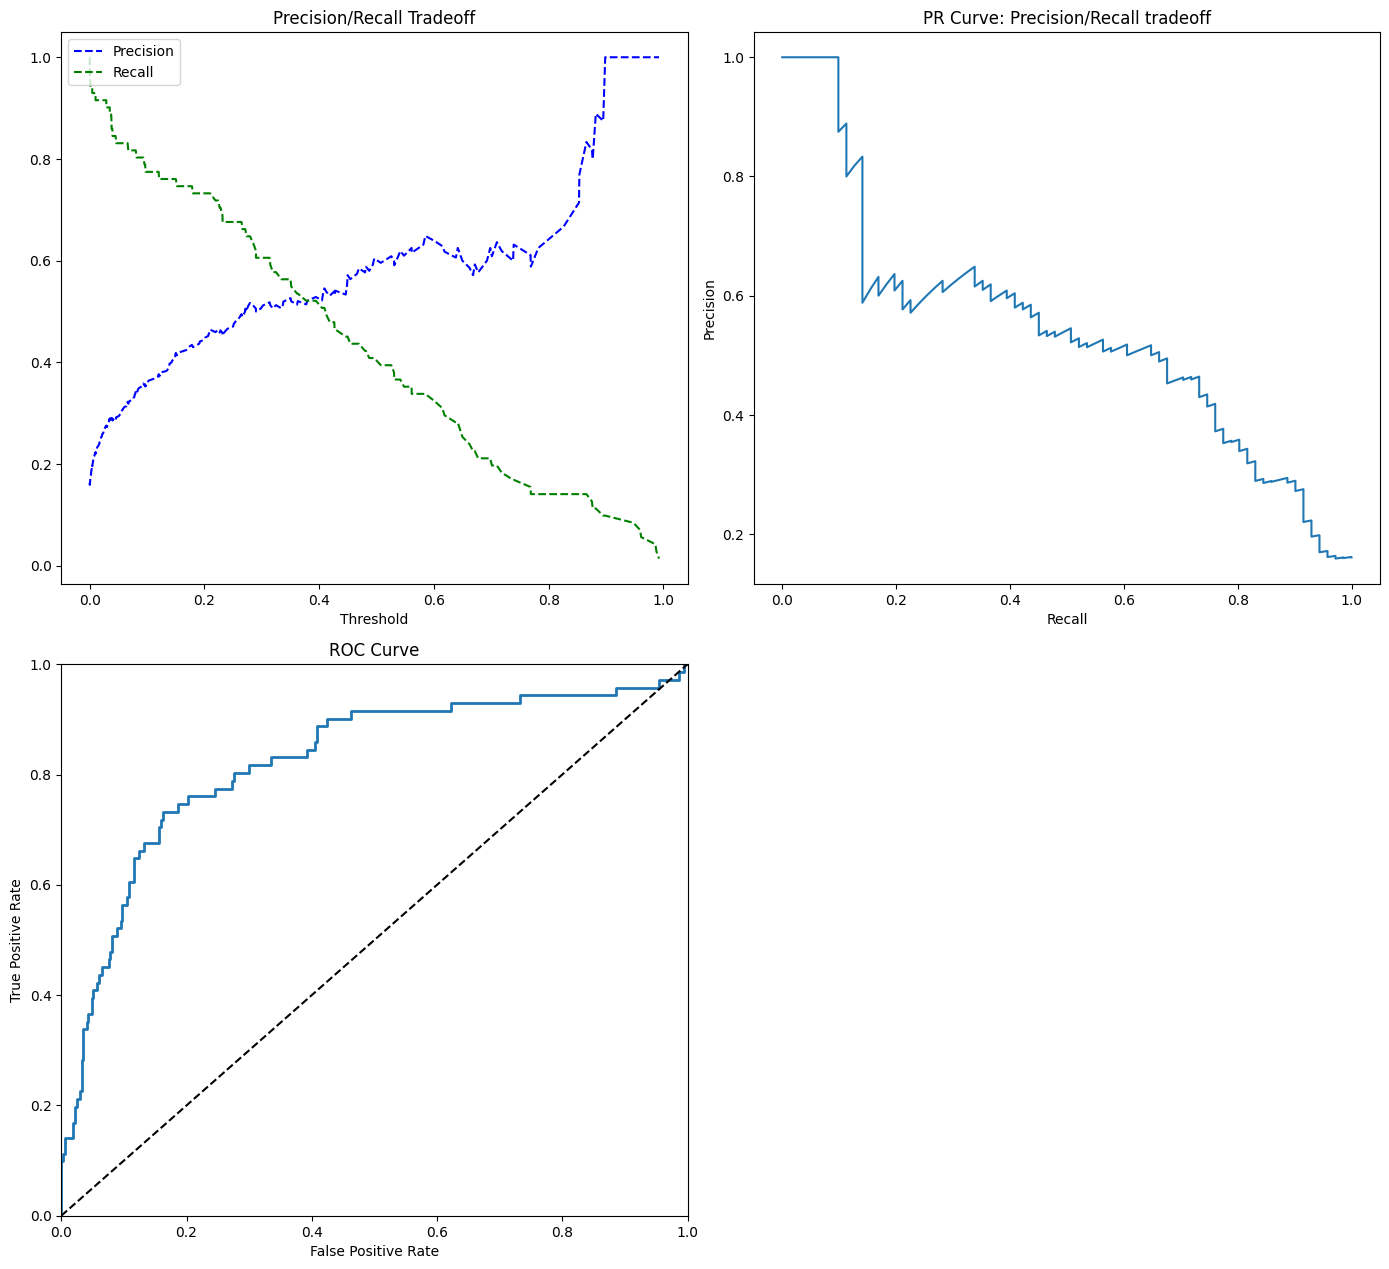

In [16]:
from sklearn.metrics import precision_recall_curve, roc_curve

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.title("Precision/Recall Tradeoff")
    
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], "k--")
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')

# Obtener predicciones
y_pred_proba = lr_clf.predict_proba(X_test_std)[:, 1]

# Calcular métricas
precisions, recalls, thresholds = precision_recall_curve(y_test_numeric, y_pred_proba)
fpr, tpr, thresholds_roc = roc_curve(y_test_numeric, y_pred_proba)

# Graficar
plt.figure(figsize=(14, 25))
plt.subplot(4, 2, 1)
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)

plt.subplot(4, 2, 2)
plt.plot(recalls, precisions)  # Nota: recalls en x, precisions en y
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve: Precision/Recall tradeoff")

plt.subplot(4, 2, 3)
plot_roc_curve(fpr, tpr)

plt.tight_layout()
plt.show()

In [17]:
# Calcular ROC AUC con probabilidades
scores_dict = {
    'Logistic Regression': {
        'Train': roc_auc_score(y_train_numeric, lr_clf.predict_proba(X_train)[:, 1]),
        'Test': roc_auc_score(y_test_numeric, lr_clf.predict_proba(X_test)[:, 1]),
    },
}
scores_dict

/Users/caguirre/Desktop/Maestria DS/Ciclo3/MLOPS/Trabajo-Final/env/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/caguirre/Desktop/Maestria DS/Ciclo3/MLOPS/Trabajo-Final/env/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


{'Logistic Regression': {'Train': 0.5666105906825448,
  'Test': 0.5664065473924629}}

## ✔️ Random Forest Classifier

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, bootstrap=False,
#                                      class_weight={0:stay, 1:leave}
                                    )
rf_clf.fit(X_train, y_train)
evaluate(rf_clf, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[863   0]
 [  0 166]]
ACCURACY SCORE:
1.0000
CLASSIFICATION REPORT:
              No    Yes  accuracy  macro avg  weighted avg
precision    1.0    1.0       1.0        1.0           1.0
recall       1.0    1.0       1.0        1.0           1.0
f1-score     1.0    1.0       1.0        1.0           1.0
support    863.0  166.0       1.0     1029.0        1029.0
TESTING RESULTS: 
CONFUSION MATRIX:
[[358  12]
 [ 62   9]]
ACCURACY SCORE:
0.8322
CLASSIFICATION REPORT:
                   No        Yes  accuracy   macro avg  weighted avg
precision    0.852381   0.428571    0.8322    0.640476      0.784149
recall       0.967568   0.126761    0.8322    0.547164      0.832200
f1-score     0.906329   0.195652    0.8322    0.550991      0.791912
support    370.000000  71.000000    0.8322  441.000000    441.000000


In [19]:
param_grid = dict(
    n_estimators= [100, 500], 
    max_features= ['auto', 'sqrt'],
    max_depth= [2, 5, 10, None], 
    min_samples_split= [2, 5, 10],
    min_samples_leaf= [1, 2, 4], 
    bootstrap= [True, False]
)

rf_clf = RandomForestClassifier(random_state=42)
search = GridSearchCV(rf_clf, param_grid=param_grid, scoring='roc_auc', cv=3, verbose=1, n_jobs=-1)
search.fit(X_train, y_train)

rf_clf = RandomForestClassifier(**search.best_params_, random_state=42)
rf_clf.fit(X_train, y_train)
evaluate(rf_clf, X_train, X_test, y_train, y_test)

Fitting 3 folds for each of 288 candidates, totalling 864 fits


/Users/caguirre/Desktop/Maestria DS/Ciclo3/MLOPS/Trabajo-Final/env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
432 fits failed out of a total of 864.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
182 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/caguirre/Desktop/Maestria DS/Ciclo3/MLOPS/Trabajo-Final/env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/caguirre/Desktop/Maestria DS/Ciclo3/MLOPS/Trabajo-Final/env/lib/python3.10/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
  File "/Users/caguirre/

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[863   0]
 [ 99  67]]
ACCURACY SCORE:
0.9038
CLASSIFICATION REPORT:
                   No         Yes  accuracy    macro avg  weighted avg
precision    0.897089    1.000000   0.90379     0.948545      0.913691
recall       1.000000    0.403614   0.90379     0.701807      0.903790
f1-score     0.945753    0.575107   0.90379     0.760430      0.885960
support    863.000000  166.000000   0.90379  1029.000000   1029.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[363   7]
 [ 67   4]]
ACCURACY SCORE:
0.8322
CLASSIFICATION REPORT:
                   No        Yes  accuracy   macro avg  weighted avg
precision    0.844186   0.363636    0.8322    0.603911      0.766819
recall       0.981081   0.056338    0.8322    0.518710      0.832200
f1-score     0.907500   0.097561    0.8322    0.502530      0.777102
support    370.000000  71.000000    0.8322  441.000000    441.000000


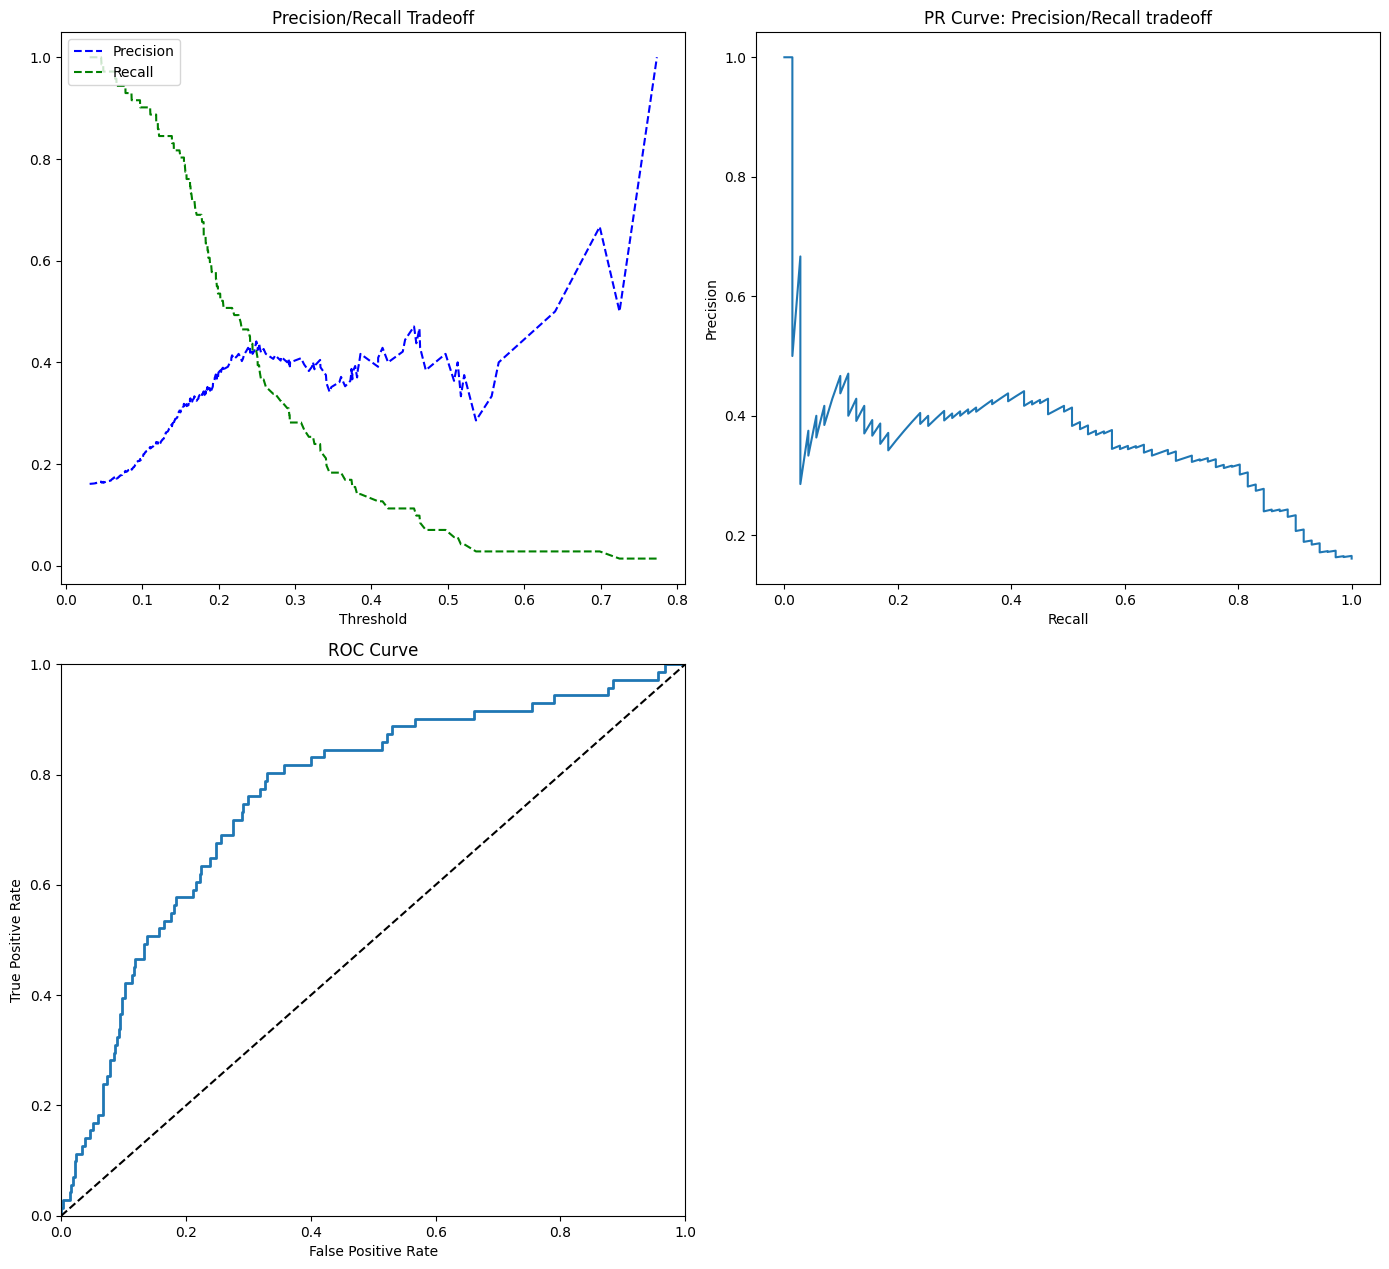

In [20]:
# Obtener probabilidades de la clase positiva
y_pred_proba = rf_clf.predict_proba(X_test)[:, 1]

# Calcular las curvas
precisions, recalls, thresholds_pr = precision_recall_curve(y_test_numeric, y_pred_proba)
fpr, tpr, thresholds_roc = roc_curve(y_test_numeric, y_pred_proba)

# Graficar
plt.figure(figsize=(14, 25))

plt.subplot(4, 2, 1)
plot_precision_recall_vs_threshold(precisions, recalls, thresholds_pr)

plt.subplot(4, 2, 2)
plt.plot(recalls, precisions)  # Nota: recalls en X, precisions en Y
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve: Precision/Recall tradeoff")

plt.subplot(4, 2, 3)
plot_roc_curve(fpr, tpr)

plt.tight_layout()
plt.show()

In [21]:
# Calcular ROC AUC usando probabilidades (mejor práctica)
scores_dict['Random Forest'] = {
    'Train': roc_auc_score(y_train_numeric, rf_clf.predict_proba(X_train)[:, 1]),
    'Test': roc_auc_score(y_test_numeric, rf_clf.predict_proba(X_test)[:, 1]),
}
scores_dict

{'Logistic Regression': {'Train': 0.5666105906825448,
  'Test': 0.5664065473924629},
 'Random Forest': {'Train': 0.9971380306858955, 'Test': 0.7623524933384089}}

Text(0.5, 1.0, 'Feature Importance according to Random Forest')

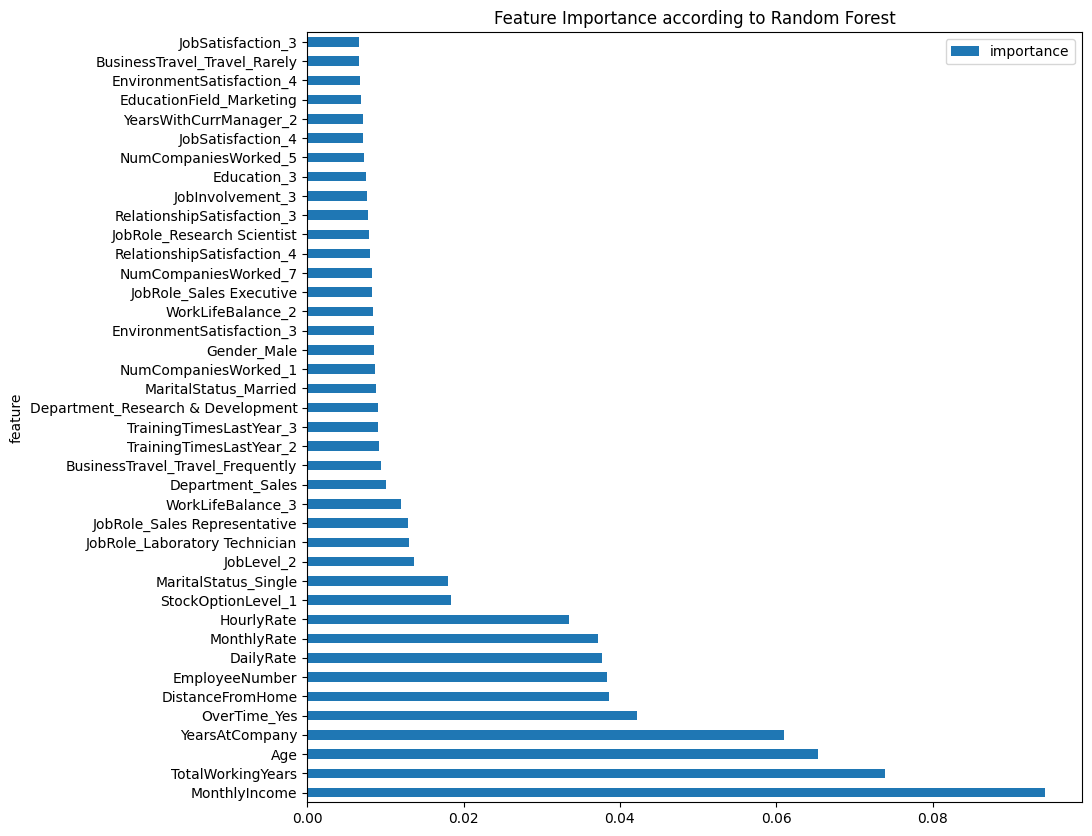

In [22]:
df = feature_imp(X, rf_clf)[:40]
df.set_index('feature', inplace=True)
df.plot(kind='barh', figsize=(10, 10))
plt.title('Feature Importance according to Random Forest')

## ✔️ Support Vector Machine

In [23]:
from sklearn.svm import SVC

svm_clf = SVC(kernel='linear')
svm_clf.fit(X_train_std, y_train)

evaluate(svm_clf, X_train_std, X_test_std, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[857   6]
 [ 48 118]]
ACCURACY SCORE:
0.9475
CLASSIFICATION REPORT:
                   No         Yes  accuracy    macro avg  weighted avg
precision    0.946961    0.951613  0.947522     0.949287      0.947712
recall       0.993048    0.710843  0.947522     0.851945      0.947522
f1-score     0.969457    0.813793  0.947522     0.891625      0.944345
support    863.000000  166.000000  0.947522  1029.000000   1029.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[345  25]
 [ 46  25]]
ACCURACY SCORE:
0.8390
CLASSIFICATION REPORT:
                   No        Yes  accuracy   macro avg  weighted avg
precision    0.882353   0.500000  0.839002    0.691176      0.820795
recall       0.932432   0.352113  0.839002    0.642273      0.839002
f1-score     0.906702   0.413223  0.839002    0.659962      0.827253
support    370.000000  71.000000  0.839002  441.000000    441.000000


In [24]:
svm_clf = SVC(random_state=42)

param_grid = [
    {'C': [1, 10, 100], 'kernel': ['linear']},
    {'C': [1, 10, 100], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']}
]

search = GridSearchCV(svm_clf, param_grid=param_grid, scoring='roc_auc', cv=3, refit=True, verbose=1)
search.fit(X_train_std, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


,estimator,SVC(random_state=42)
,param_grid,"[{'C': [1, 10, ...], 'kernel': ['linear']}, {'C': [1, 10, ...], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']}]"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [25]:
svm_clf = SVC(**search.best_params_)
svm_clf.fit(X_train_std, y_train)

evaluate(svm_clf, X_train_std, X_test_std, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[862   1]
 [  6 160]]
ACCURACY SCORE:
0.9932
CLASSIFICATION REPORT:
                   No         Yes  accuracy    macro avg  weighted avg
precision    0.993088    0.993789  0.993197     0.993438      0.993201
recall       0.998841    0.963855  0.993197     0.981348      0.993197
f1-score     0.995956    0.978593  0.993197     0.987275      0.993155
support    863.000000  166.000000  0.993197  1029.000000   1029.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[346  24]
 [ 42  29]]
ACCURACY SCORE:
0.8503
CLASSIFICATION REPORT:
                   No        Yes  accuracy   macro avg  weighted avg
precision    0.891753   0.547170   0.85034    0.719461      0.836276
recall       0.935135   0.408451   0.85034    0.671793      0.850340
f1-score     0.912929   0.467742   0.85034    0.690335      0.841255
support    370.000000  71.000000   0.85034  441.000000    441.000000


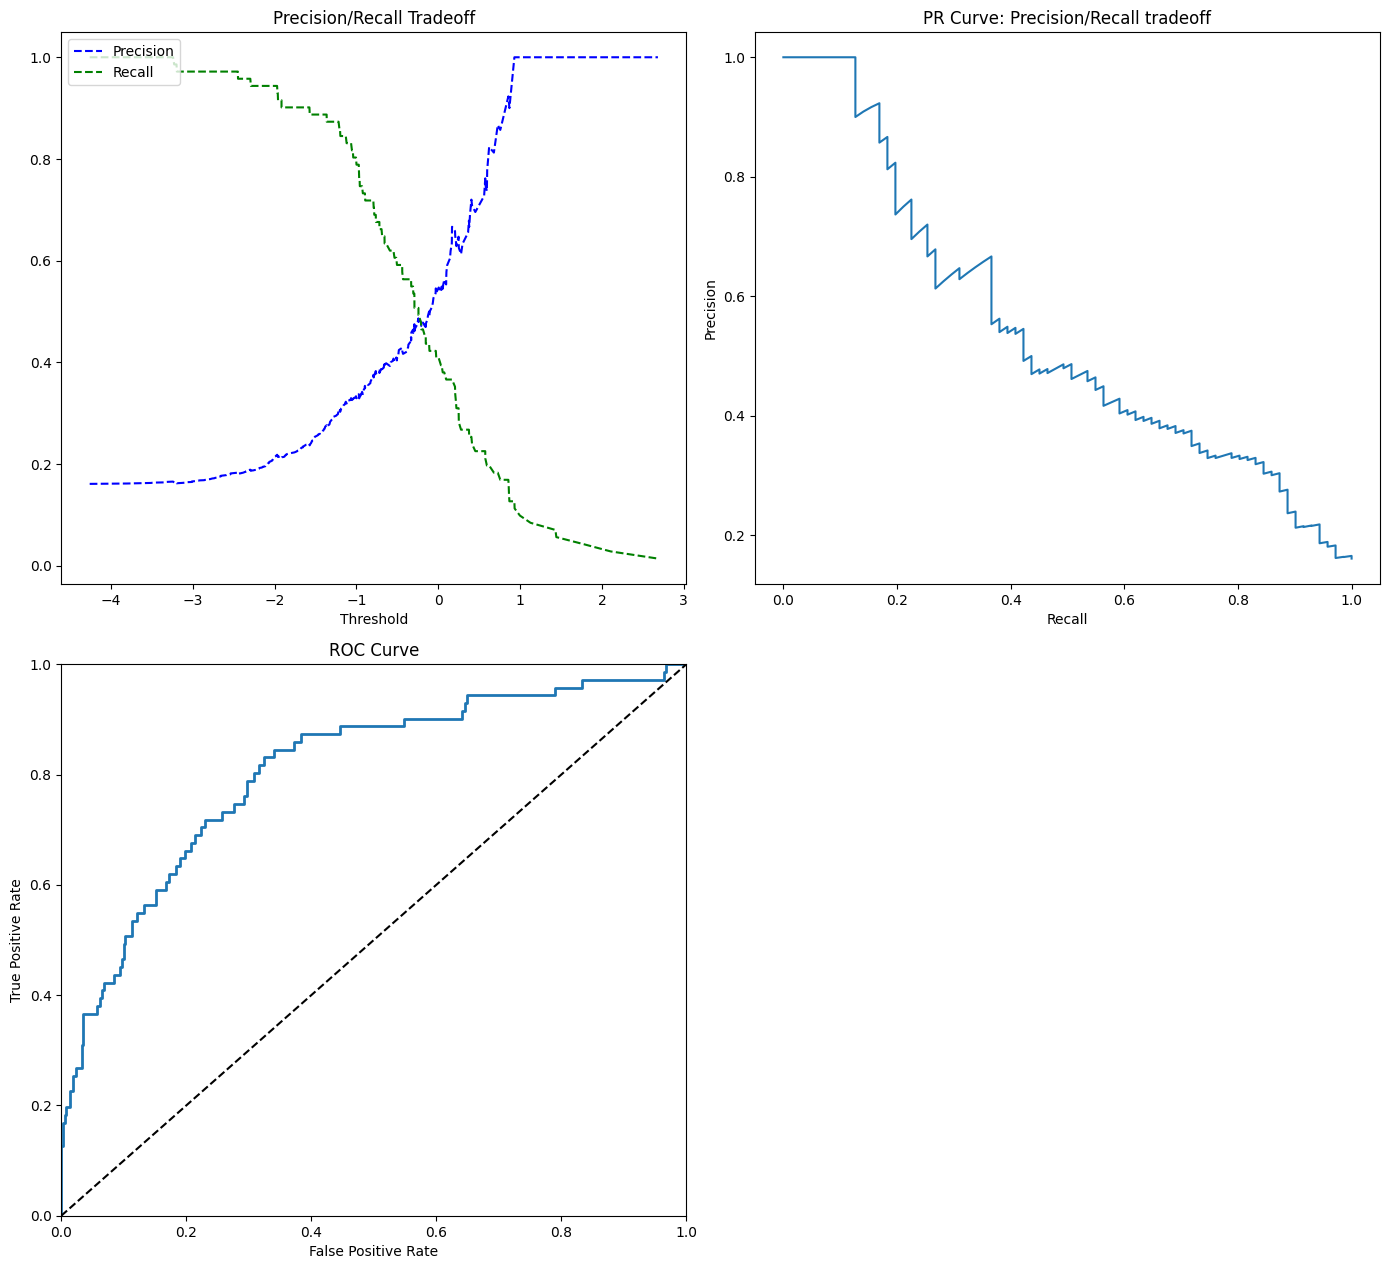

In [26]:
# Para SVM, usa decision_function() que retorna scores de confianza
y_scores = svm_clf.decision_function(X_test_std)

# Calcular las curvas
precisions, recalls, thresholds_pr = precision_recall_curve(y_test_numeric, y_scores)
fpr, tpr, thresholds_roc = roc_curve(y_test_numeric, y_scores)

# Graficar
plt.figure(figsize=(14, 25))

plt.subplot(4, 2, 1)
plot_precision_recall_vs_threshold(precisions, recalls, thresholds_pr)

plt.subplot(4, 2, 2)
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve: Precision/Recall tradeoff")

plt.subplot(4, 2, 3)
plot_roc_curve(fpr, tpr)

plt.tight_layout()
plt.show()

In [27]:
# Usar decision_function() para SVM (retorna scores de confianza)
scores_dict['Support Vector Machine'] = {
    'Train': roc_auc_score(y_train_numeric, svm_clf.decision_function(X_train_std)),
    'Test': roc_auc_score(y_test_numeric, svm_clf.decision_function(X_test_std)),
}
scores_dict

{'Logistic Regression': {'Train': 0.5666105906825448,
  'Test': 0.5664065473924629},
 'Random Forest': {'Train': 0.9971380306858955, 'Test': 0.7623524933384089},
 'Support Vector Machine': {'Train': 0.9946739449105808,
  'Test': 0.8070803197563761}}

In [28]:
from sklearn.preprocessing import LabelEncoder

# Convertir las etiquetas a numéricos
le = LabelEncoder()
y_train_numeric = le.fit_transform(y_train)
y_test_numeric = le.transform(y_test)

# Usar decision_function() para SVM (retorna scores de confianza)
scores_dict['Support Vector Machine'] = {
    'Train': roc_auc_score(y_train_numeric, svm_clf.decision_function(X_train_std)),
    'Test': roc_auc_score(y_test_numeric, svm_clf.decision_function(X_test_std)),
}
scores_dict

{'Logistic Regression': {'Train': 0.5666105906825448,
  'Test': 0.5664065473924629},
 'Random Forest': {'Train': 0.9971380306858955, 'Test': 0.7623524933384089},
 'Support Vector Machine': {'Train': 0.9946739449105808,
  'Test': 0.8070803197563761}}

## ✔️ XGBoost Classifier

In [29]:
from xgboost import XGBClassifier

# 2. Convertir X_train y X_test a tipos numéricos
X_train = X_train.astype('float64')
X_test = X_test.astype('float64')

# 3. Entrenar XGBoost
xgb_clf = XGBClassifier()
xgb_clf.fit(X_train, y_train_numeric)

# 4. Evaluar
evaluate(xgb_clf, X_train, X_test, y_train_numeric, y_test_numeric)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[863   0]
 [  0 166]]
ACCURACY SCORE:
1.0000
CLASSIFICATION REPORT:
               0      1  accuracy  macro avg  weighted avg
precision    1.0    1.0       1.0        1.0           1.0
recall       1.0    1.0       1.0        1.0           1.0
f1-score     1.0    1.0       1.0        1.0           1.0
support    863.0  166.0       1.0     1029.0        1029.0
TESTING RESULTS: 
CONFUSION MATRIX:
[[358  12]
 [ 47  24]]
ACCURACY SCORE:
0.8662
CLASSIFICATION REPORT:
                    0          1  accuracy   macro avg  weighted avg
precision    0.883951   0.666667  0.866213    0.775309      0.848968
recall       0.967568   0.338028  0.866213    0.652798      0.866213
f1-score     0.923871   0.448598  0.866213    0.686235      0.847353
support    370.000000  71.000000  0.866213  441.000000    441.000000


In [30]:
scores_dict['XGBoost'] = {
        'Train': roc_auc_score(y_train, xgb_clf.predict(X_train)),
        'Test': roc_auc_score(y_test, xgb_clf.predict(X_test)),
    }
scores_dict

{'Logistic Regression': {'Train': 0.5666105906825448,
  'Test': 0.5664065473924629},
 'Random Forest': {'Train': 0.9971380306858955, 'Test': 0.7623524933384089},
 'Support Vector Machine': {'Train': 0.9946739449105808,
  'Test': 0.8070803197563761},
 'XGBoost': {'Train': 1.0, 'Test': 0.6527978682908261}}

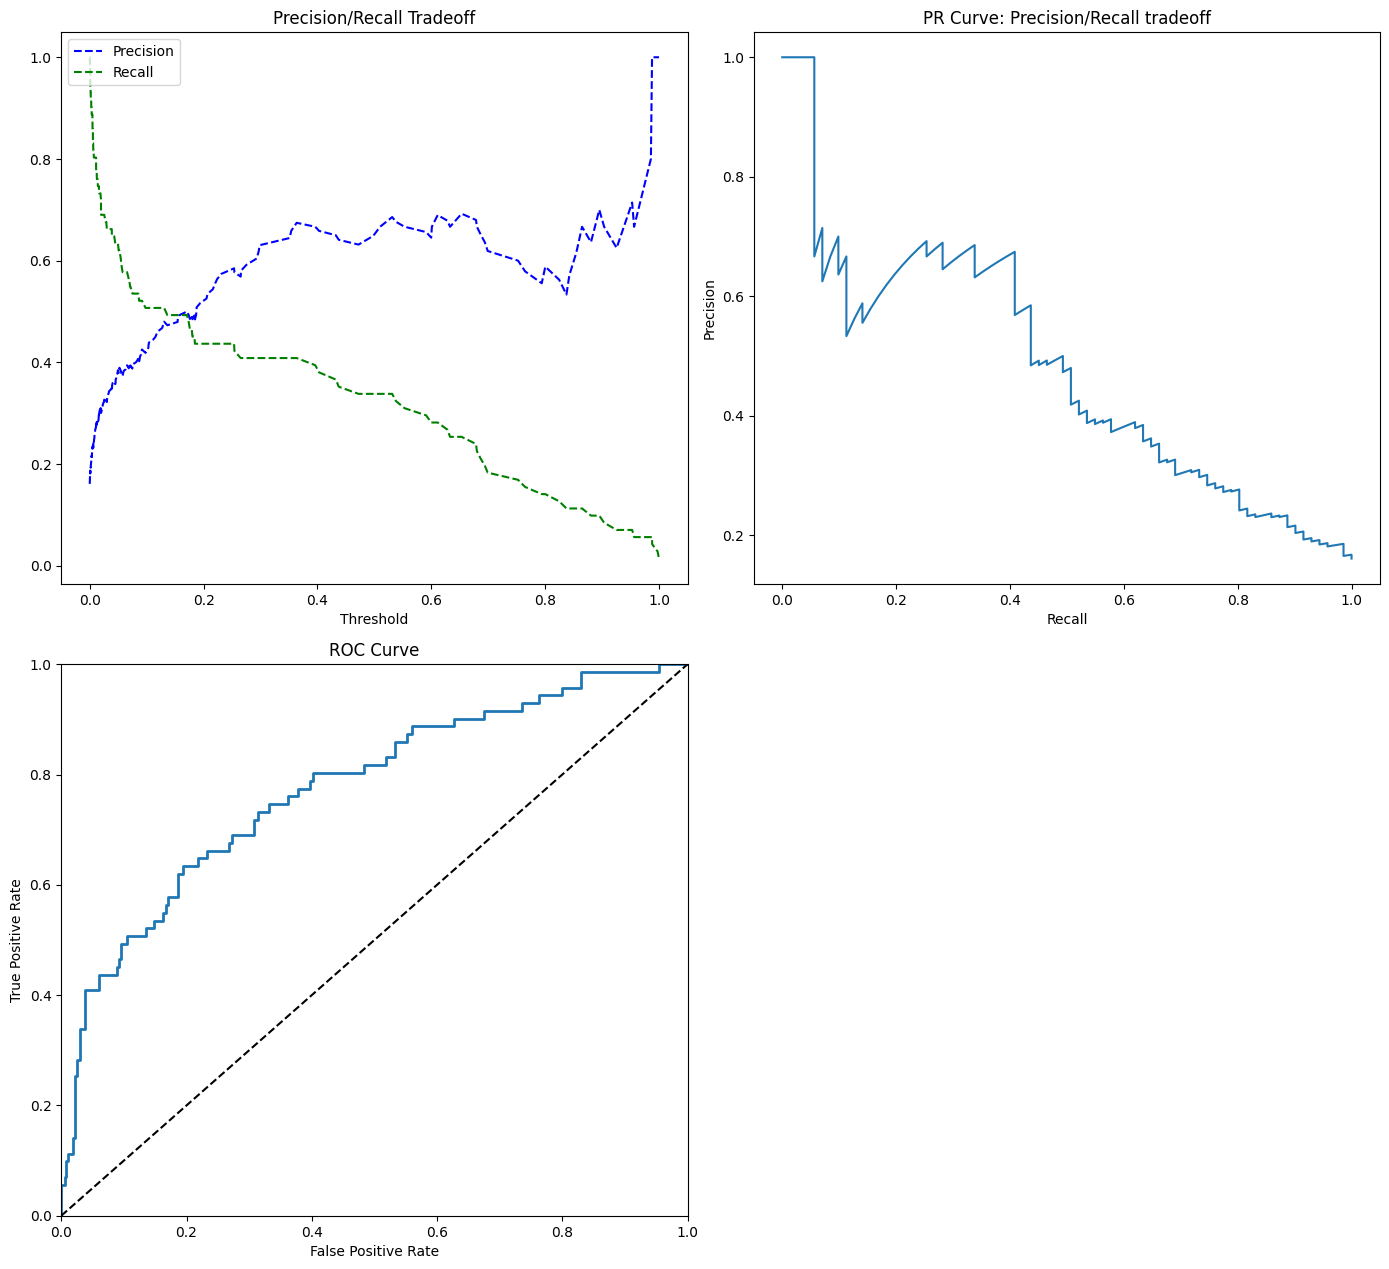

In [31]:
# Usar predict_proba() para obtener probabilidades
y_pred_proba = xgb_clf.predict_proba(X_test)[:, 1]

# Calcular las curvas
precisions, recalls, thresholds_pr = precision_recall_curve(y_test_numeric, y_pred_proba)
fpr, tpr, thresholds_roc = roc_curve(y_test_numeric, y_pred_proba)

# Graficar
plt.figure(figsize=(14, 25))

plt.subplot(4, 2, 1)
plot_precision_recall_vs_threshold(precisions, recalls, thresholds_pr)

plt.subplot(4, 2, 2)
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve: Precision/Recall tradeoff")

plt.subplot(4, 2, 3)
plot_roc_curve(fpr, tpr)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Feature Importance according to XGBoost')

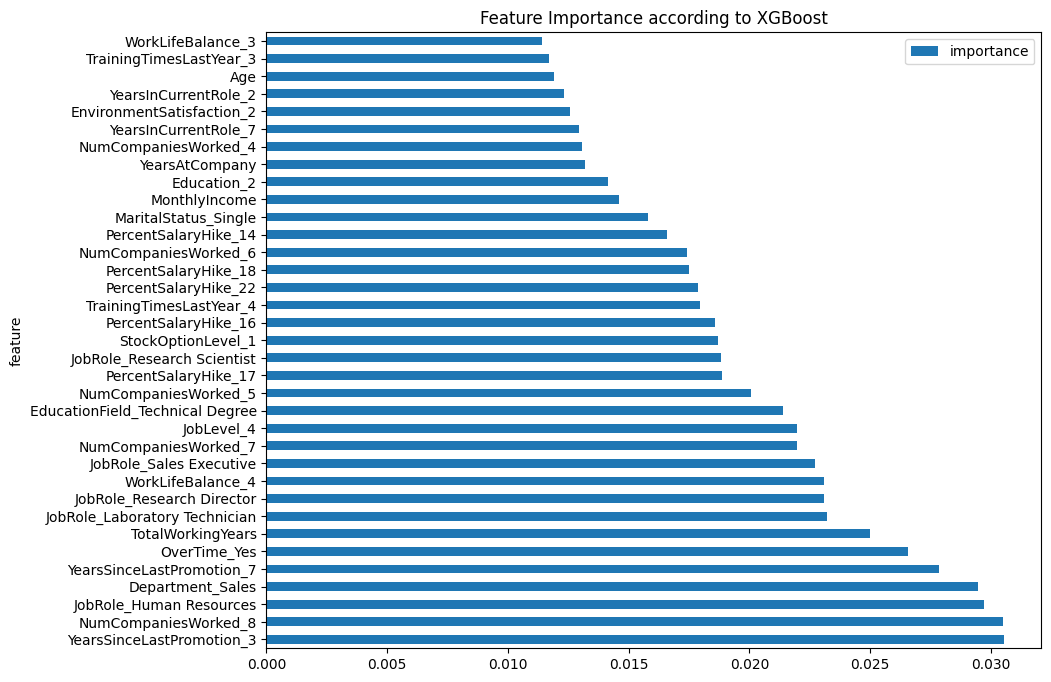

In [32]:
df = feature_imp(X, xgb_clf)[:35]
df.set_index('feature', inplace=True)
df.plot(kind='barh', figsize=(10, 8))
plt.title('Feature Importance according to XGBoost')

## ✔️ LightGBM

In [33]:
from lightgbm import LGBMClassifier

lgb_clf = LGBMClassifier()
lgb_clf.fit(X_train, y_train)

evaluate(lgb_clf, X_train, X_test, y_train, y_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 166, number of negative: 863
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000852 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1431
[LightGBM] [Info] Number of data points in the train set: 1029, number of used features: 109
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161322 -> initscore=-1.648427
[LightGBM] [Info] Start training from score -1.648427
TRAINIG RESULTS: 
CONFUSION MATRIX:
[[863   0]
 [  0 166]]
ACCURACY SCORE:
1.0000
CLASSIFICATION REPORT:
              No    Yes  accuracy  macro avg  weighted avg
precision    1.0    1.0       1.0        1.0           1.0
recall       1.0    1.0       1.0        1.0           1.0
f1-score     1.0    1.0       1.0        1.0           1.0
support    863.0  166.0       1.0     1029.0        1029.0
TESTING RESULTS: 
CONFUSION MA

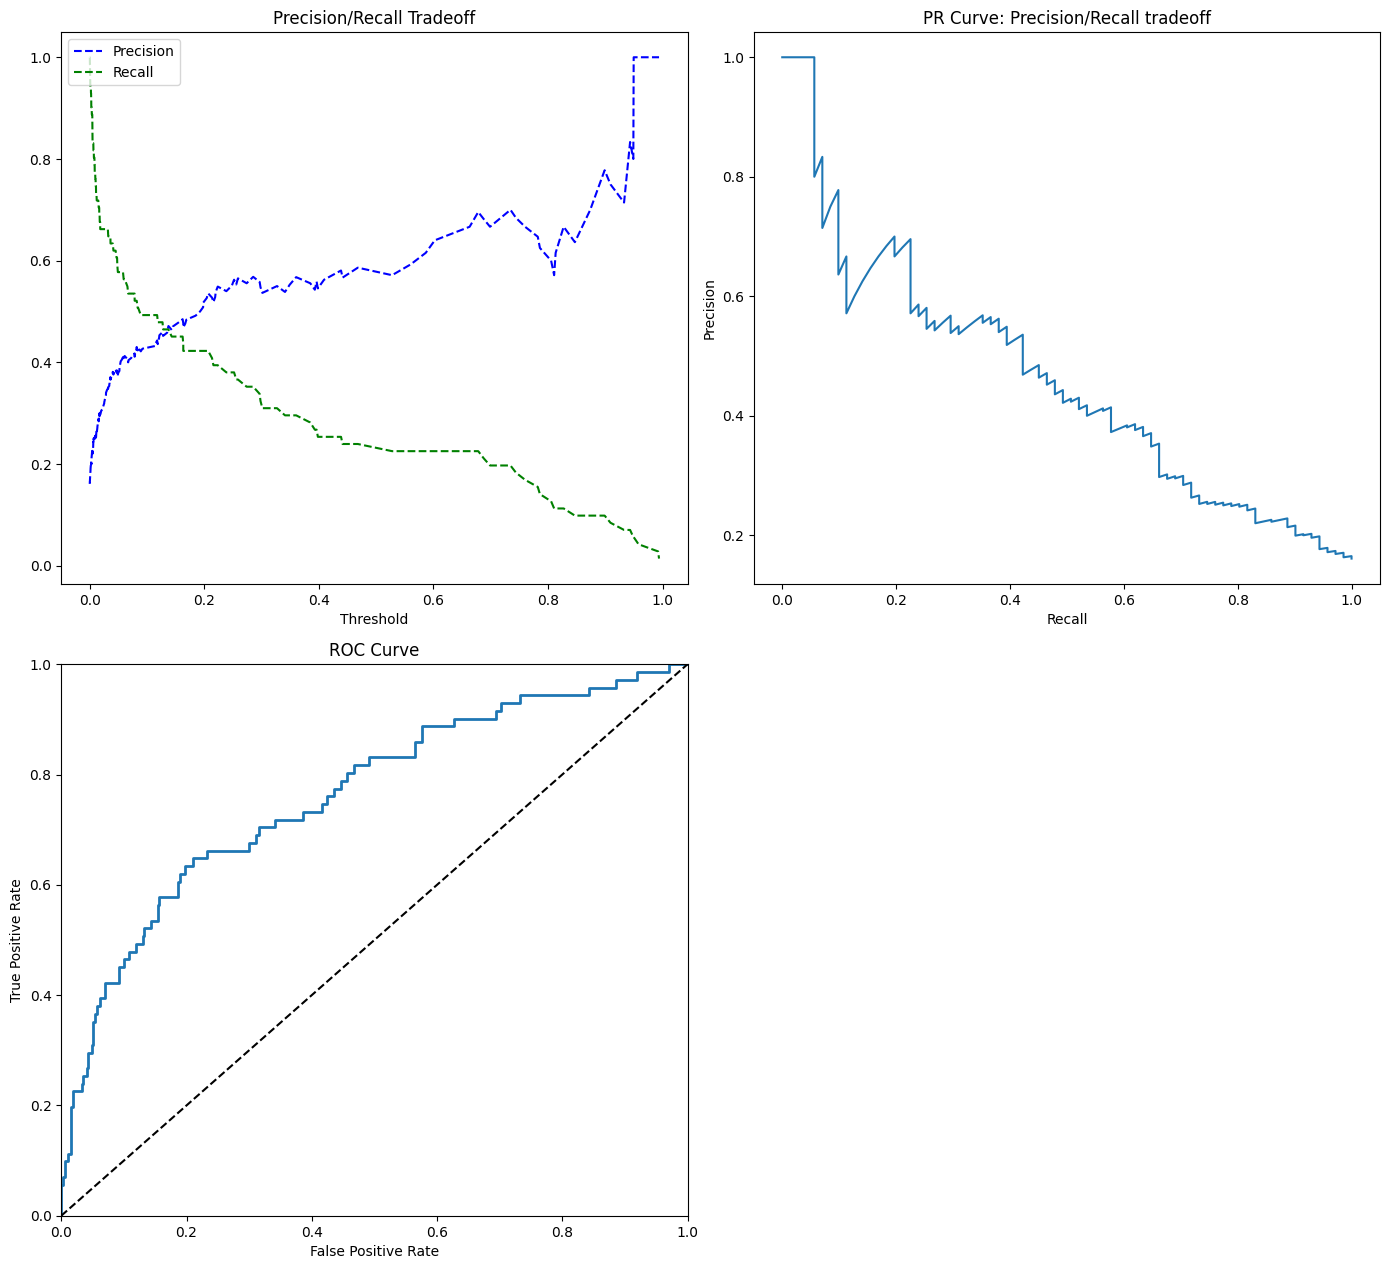

In [34]:
# Usar predict_proba() para obtener probabilidades
y_pred_proba = lgb_clf.predict_proba(X_test)[:, 1]

# Calcular las curvas
precisions, recalls, thresholds_pr = precision_recall_curve(y_test_numeric, y_pred_proba)
fpr, tpr, thresholds_roc = roc_curve(y_test_numeric, y_pred_proba)

# Graficar
plt.figure(figsize=(14, 25))

plt.subplot(4, 2, 1)
plot_precision_recall_vs_threshold(precisions, recalls, thresholds_pr)

plt.subplot(4, 2, 2)
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve: Precision/Recall tradeoff")

plt.subplot(4, 2, 3)
plot_roc_curve(fpr, tpr)

plt.tight_layout()
plt.show()

In [35]:
# Usar probabilidades (mejor práctica para ROC AUC)
scores_dict['LightGBM'] = {
    'Train': roc_auc_score(y_train_numeric, lgb_clf.predict_proba(X_train)[:, 1]),
    'Test': roc_auc_score(y_test_numeric, lgb_clf.predict_proba(X_test)[:, 1]),
}

scores_dict

{'Logistic Regression': {'Train': 0.5666105906825448,
  'Test': 0.5664065473924629},
 'Random Forest': {'Train': 0.9971380306858955, 'Test': 0.7623524933384089},
 'Support Vector Machine': {'Train': 0.9946739449105808,
  'Test': 0.8070803197563761},
 'XGBoost': {'Train': 1.0, 'Test': 0.6527978682908261},
 'LightGBM': {'Train': 1.0, 'Test': 0.7619337647506662}}

# 🎯 Comparando Modelos 📊

In [36]:
# Usar probabilidades para ROC AUC
ml_models = {
    'Random Forest': rf_clf, 
    'XGBoost': xgb_clf, 
    'Logistic Regression': lr_clf,
    'Support Vector Machine': svm_clf,
    'LightGBM': lgb_clf
}

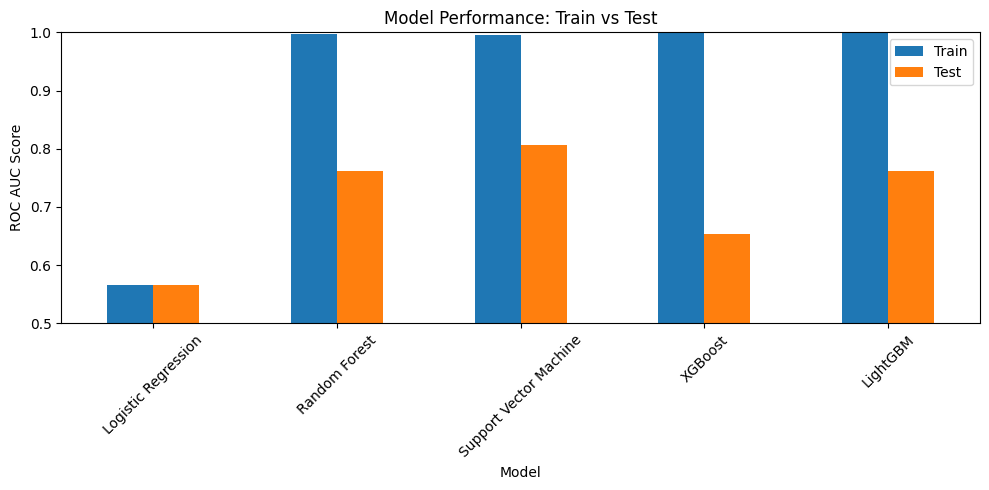

In [37]:
scores_df = pd.DataFrame(scores_dict)
# Transponer para mejor visualización
scores_df.T.plot(kind='bar', figsize=(10, 5), rot=45)
plt.xlabel('Model')
plt.ylabel('ROC AUC Score')
plt.title('Model Performance: Train vs Test')
plt.legend(['Train', 'Test'])
plt.ylim([0.5, 1.0])  # Ajusta según tus scores
plt.tight_layout()

# Guardar la figura ANTES de plt.show()
plt.savefig('../reports/model_performance_experiment.png', dpi=300, bbox_inches='tight')

plt.show()

In [38]:
for model_name, model in ml_models.items():
    # Para SVM usa decision_function, para el resto usa predict_proba
    if model_name == 'Support Vector Machine':
        y_scores = model.decision_function(X_test)
    else:
        y_scores = model.predict_proba(X_test)[:, 1]
    
    score = roc_auc_score(y_test_numeric, y_scores)
    print(f"{model_name.upper():{30}} roc_auc_score: {score:.3f}")

RANDOM FOREST                  roc_auc_score: 0.762
XGBOOST                        roc_auc_score: 0.776
LOGISTIC REGRESSION            roc_auc_score: 0.566
SUPPORT VECTOR MACHINE         roc_auc_score: 0.500
LIGHTGBM                       roc_auc_score: 0.762


/Users/caguirre/Desktop/Maestria DS/Ciclo3/MLOPS/Trabajo-Final/env/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/caguirre/Desktop/Maestria DS/Ciclo3/MLOPS/Trabajo-Final/env/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


#### Observando los resultados y teniendo en cuenta que para este problema nos interesa más el f1-score porque queremos predecir con exactitud cuantos empleados renunciaran a la empresa (recall sobre el target positivo='SI'), pero considerando un bajo margen de falsos positivos (alta precisión).

#### El modelo que tiene más alto f1-score es LogisticRegression (0.47), será nuestro modelo final